# random init state

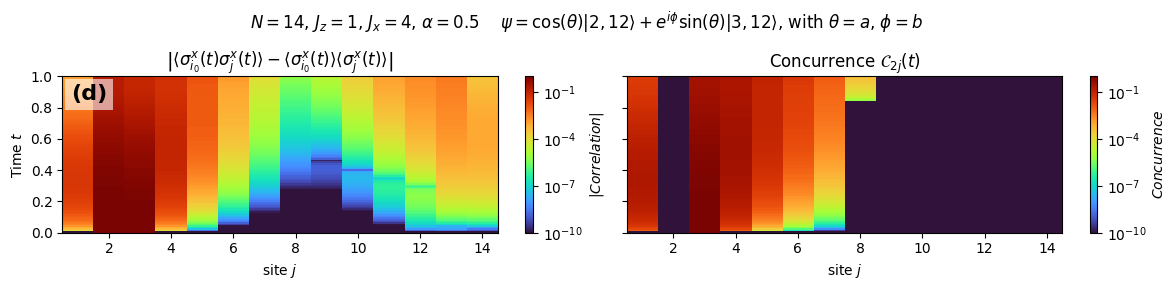

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

valuesList=[1]

thetalist=["a"]
philist=["b"]

for value in valuesList:
    # -------------------------
    # SETTINGS
    # -------------------------
    outdir = "ED_Data/Projected/"
    i0 = 1            # python index for "site 2" in the paper
    t_max_plot = 10
    alpha = 0.5
    N = 14
    Jz = 1
    Jx = 4

    vmin_corr = 1e-10
    vmin_conc = 1e-10

    prefix = "initvary1"
    panel_letter = "(d)"

    # -------------------------
    # LOAD DATA
    # -------------------------
    df_corr = pd.read_csv(f"{outdir}/{prefix}corrzz.csv")
    df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")

    # -------------------------
    # TIME AXIS (MASTER)
    # -------------------------
    t = df_corr["t"].values
    mask = t <= t_max_plot
    t_plot = t[mask]
    t_min, t_max = t_plot.min(), t_plot.max()

    # -------------------------
    # CONNECTED CORRELATIONS C_{2j}^{xx,conn}
    # -------------------------
    C_cols = [c for c in df_corr.columns if c.startswith(f"Czz_{i0}_")]
    j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
    order = np.argsort(j_vals)

    CorrMat = np.abs(df_corr[C_cols].values[:, order])
    CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
    CorrMat = CorrMat[mask, :]

    # -------------------------
    # CONCURRENCE C_{2j}
    # -------------------------
    ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
    # Align columns with CorrMat ordering
    ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]

    ConMat = df_conc[ConCols].values
    ConMat = np.clip(ConMat, vmin_conc, 1.0)
    ConMat = ConMat[mask, :]

    # -------------------------
    # PLOT (2 PANELS)
    # -------------------------
    fig, ax = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

    extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

    # (1) Connected correlations
    im1 = ax[0].imshow(
        CorrMat,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
        extent=extent,
    )
    ax[0].set_title(
        r"$\left|\langle \sigma_{i_0}^x(t)\sigma_j^x(t)\rangle"
        r"-\langle \sigma_{i_0}^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
    )
    ax[0].set_ylabel(r"Time $t$")
    ax[0].set_xlabel(r"site $j$")

    # (2) Concurrence
    im2 = ax[1].imshow(
        ConMat,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
        extent=extent,
    )
    ax[1].set_title(r"Concurrence $\mathcal{C}_{2 j}(t)$")
    ax[1].set_xlabel(r"site $j$")

    # Colorbars
    plt.colorbar(im1, ax=ax[0], label=r"$|Correlation|$")
    plt.colorbar(im2, ax=ax[1], label=r"$Concurrence$")

    # Panel letter
    ax[0].text(
        0.02, 0.95, panel_letter,
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Suptitle
    if alpha >= 100:
        plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.06)
    if value==1:
        plt.suptitle(
        rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$    "
        rf"$\psi = \cos(\theta)|2,12\rangle"
        rf" + e^{{i\phi}}\sin(\theta)|3,12\rangle$, "
        rf"with $\theta={thetalist[value-1]}$, $\phi={philist[value-1]}$",
        y=0.95
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave room for suptitle
    plt.tight_layout()
    plt.show()


# General

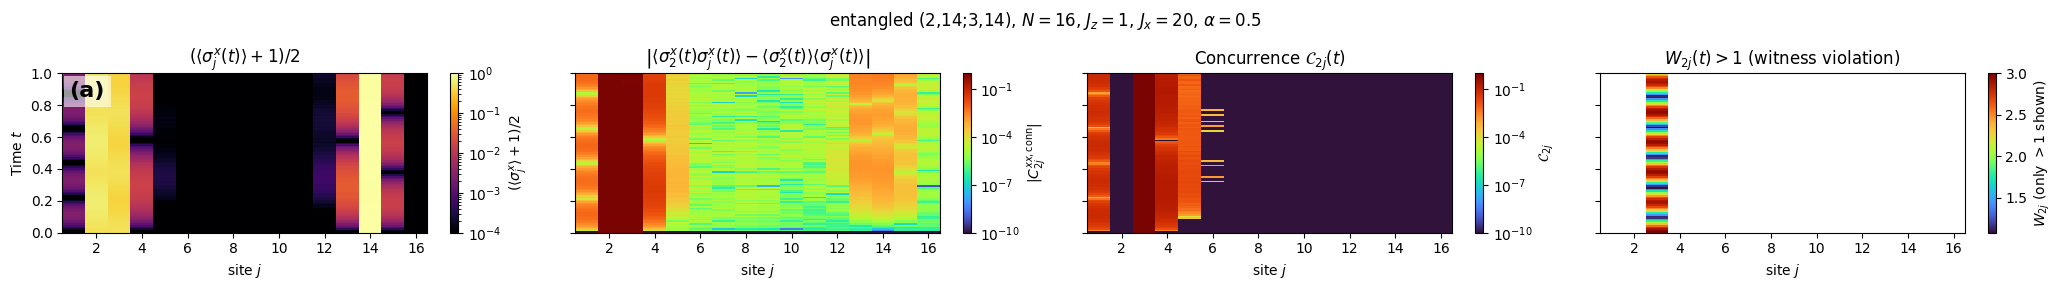

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
outdir = "ED_Data"
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 1
alpha=0.5
N=10
Jz=1
Jx=20

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10


panel_letter = "(a)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/magnetizationx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/correlations_xx_connected.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/correlations.csv")

df_conc = pd.read_csv(f"{outdir}/concurrence.csv")
df_wit  = pd.read_csv(f"{outdir}/witness.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,14;3,14), $N=16$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDWitness1.pdf")
plt.show()


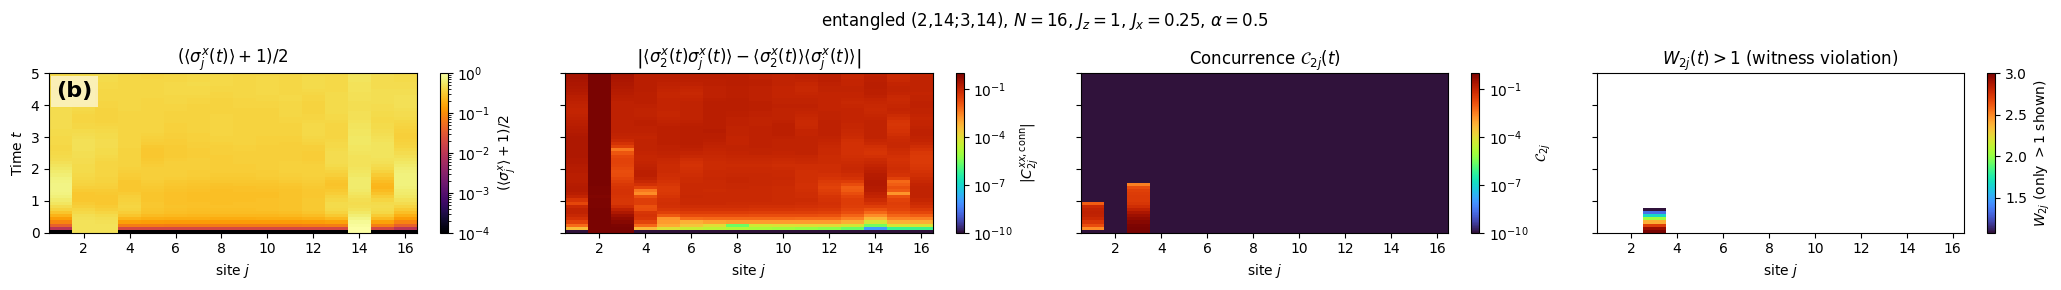

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
outdir = "ED_Data/Jx025"
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 5
alpha=0.5
N=10
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10


panel_letter = "(b)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/magnetizationx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/correlations_xx_connected.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/correlations.csv")

df_conc = pd.read_csv(f"{outdir}/concurrence.csv")
df_wit  = pd.read_csv(f"{outdir}/witness.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,14;3,14), $N=16$, $J_z={Jz}$, $J_x=0.25$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDWitness2.pdf")
plt.show()


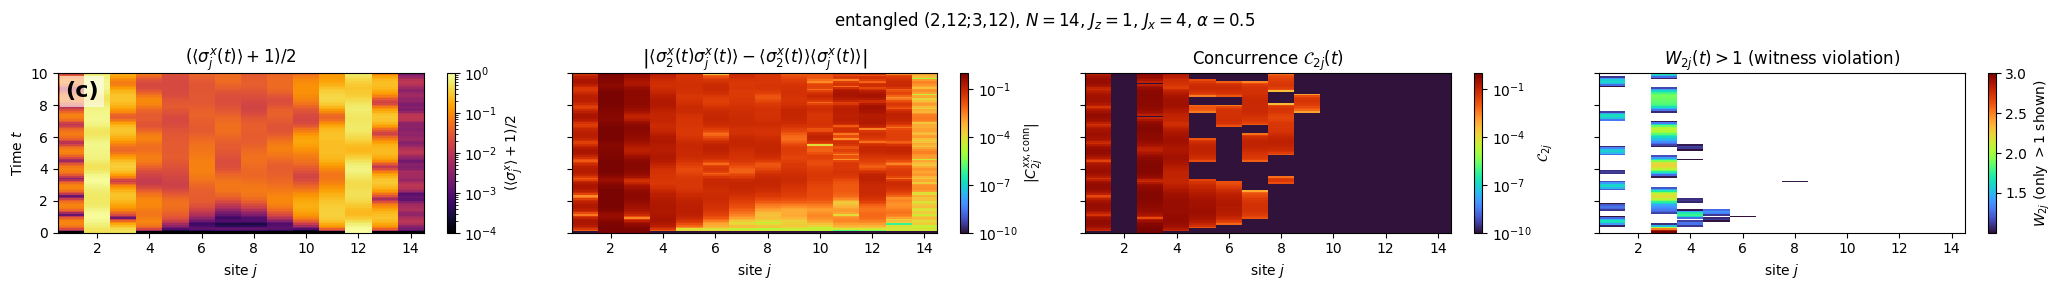

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
outdir = "ED_Data/Jx025"
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="b2"

panel_letter = "(c)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDLRb2.pdf")
plt.show()


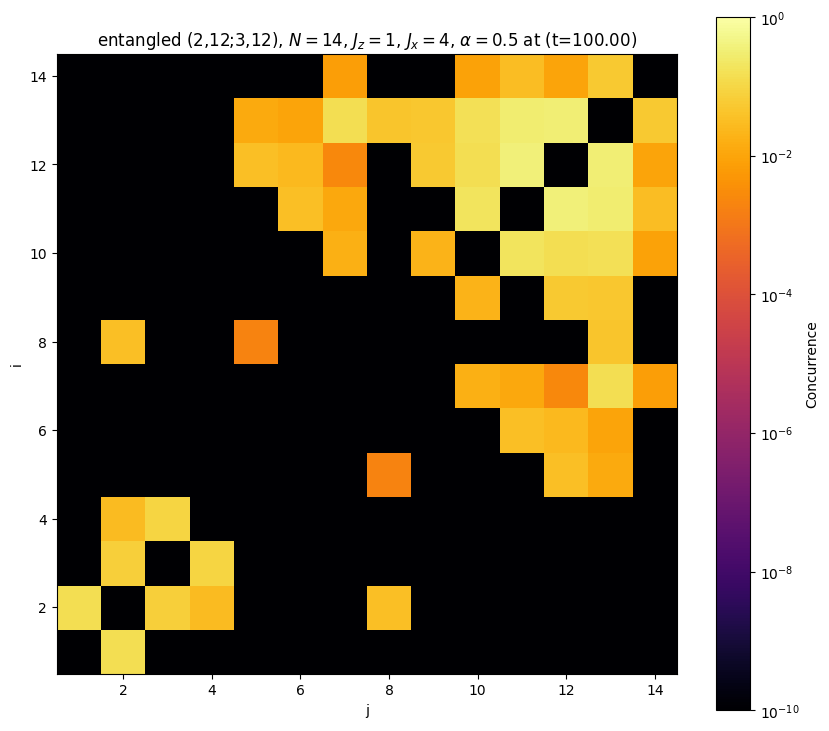

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as colors   # <-- you need this

outdir="ED_Data/Cij"
prefix="LRb2"

# -----------------------------
# load the Cij matrix CSV
# -----------------------------
csv_path = f"{outdir}/{prefix}conc.csv"  # <-- adjust filename to yours
df = pd.read_csv(csv_path)

# restrict time window if you want (same as you did)
df = df[(df["t"] >= 0.0) & (df["t"] <= 100.0)].copy()

times = df["t"].values
N=14
ns = N

# -----------------------------
# plotting setup (your style)
# -----------------------------
vmin = 1e-10
vmax = 1.0

fig, ax = plt.subplots(figsize=(10, 9))

C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# -----------------------------
# minimal: precompute column lookup
# -----------------------------
col = {(i, j): f"C_{i}_{j}" for i in range(ns) for j in range(ns)}

# -----------------------------
# update frame
# -----------------------------
def update(frame):
    row = df.iloc[frame]
    C = np.full((ns, ns), np.nan)

    for i in range(ns):
        for j in range(ns):
            val = row[col[(i, j)]]
            # LogNorm can't take 0 -> clamp
            if val <= 0:
                val = vmin
            C[i, j] = val

    im.set_data(C)
    title.set_text(rf"entangled (2,12;3,12), $N={N}$, $J_z=1$, $J_x=4$, $\alpha=0.5$ at (t={row['t']:.2f})")
    return (im,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(df),
    interval=60,
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("gif/conc_LRb2.gif", writer=PillowWriter(fps=5))


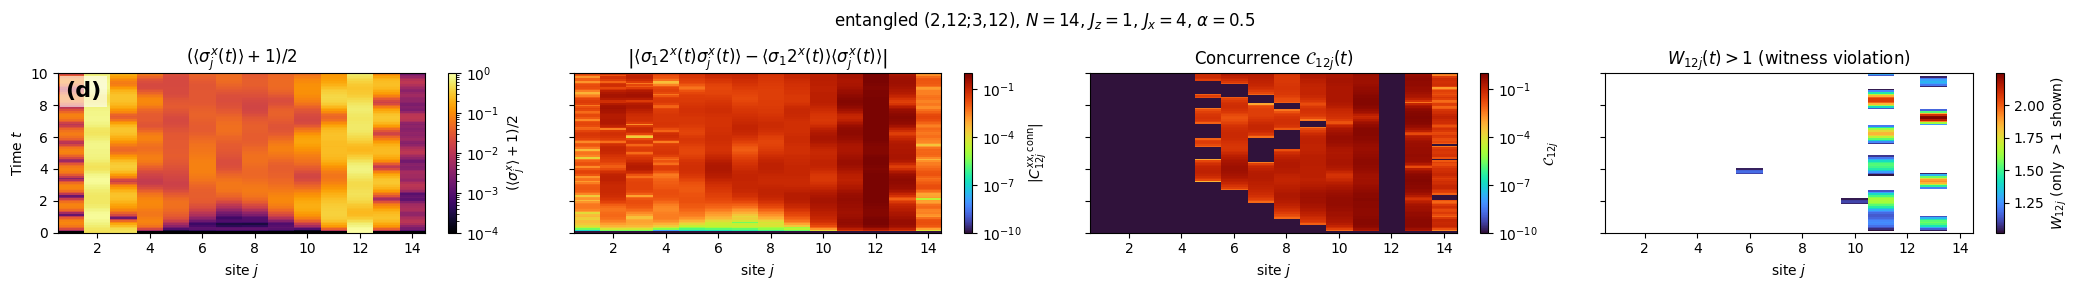

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
outdir = "ED_Data/Jx025"
i0 = 11            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="b2n"

panel_letter = "(d)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.01, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_12^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_12^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{12j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{12j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{12j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{12j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{12j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDLRb22.pdf")
plt.show()


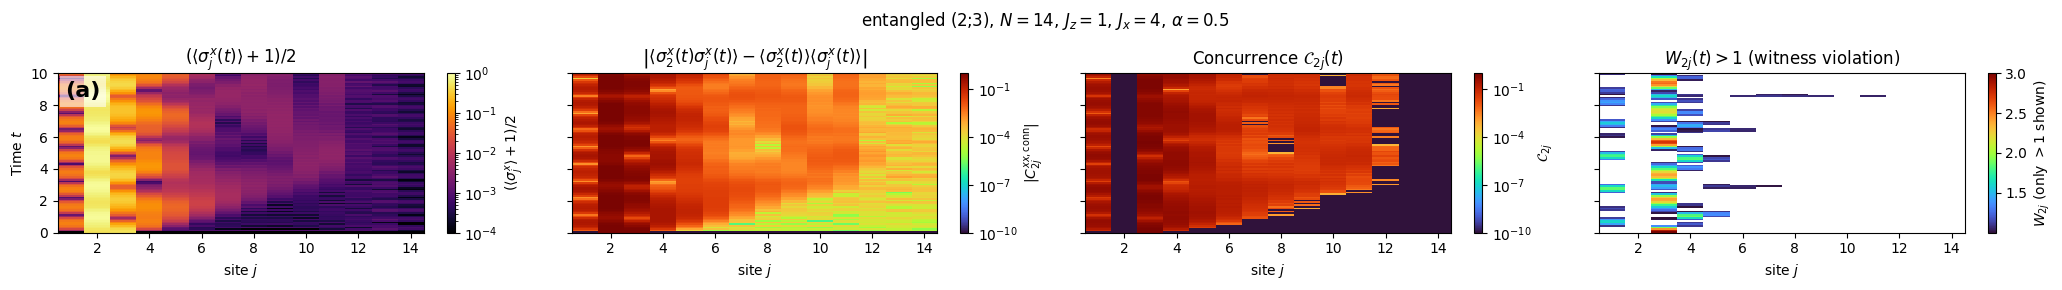

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="b1"

panel_letter = "(a)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2;3), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDLRb1.pdf")
plt.show()


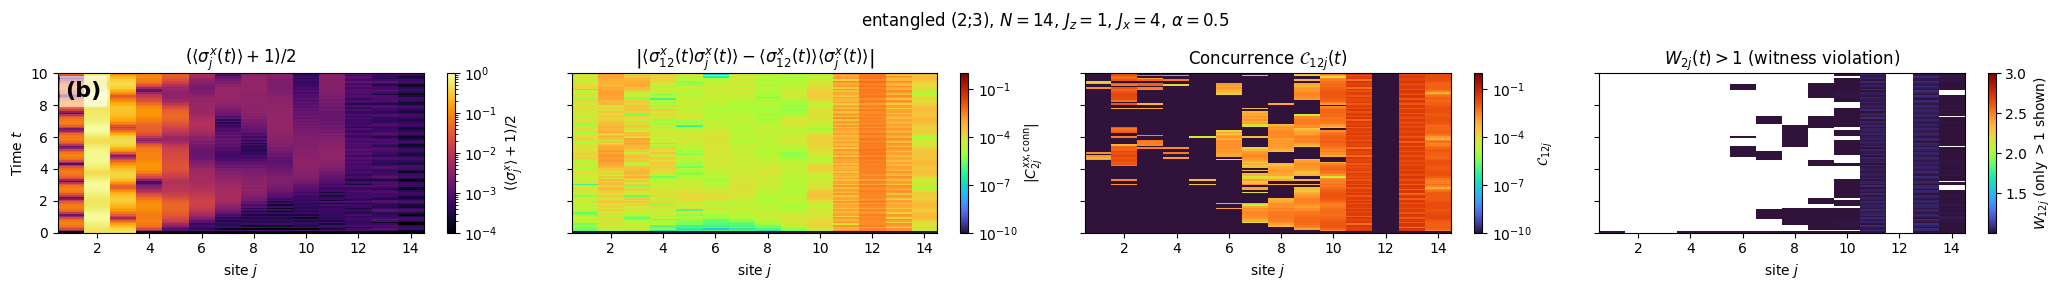

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 11            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="EDLRb12"

panel_letter = "(b)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_{12}^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_{12}^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{12j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
wit_vmax=3
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.Normalize(vmin=1.01, vmax=3),
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{12j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{12j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2;3), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDLRb12.pdf")
plt.show()


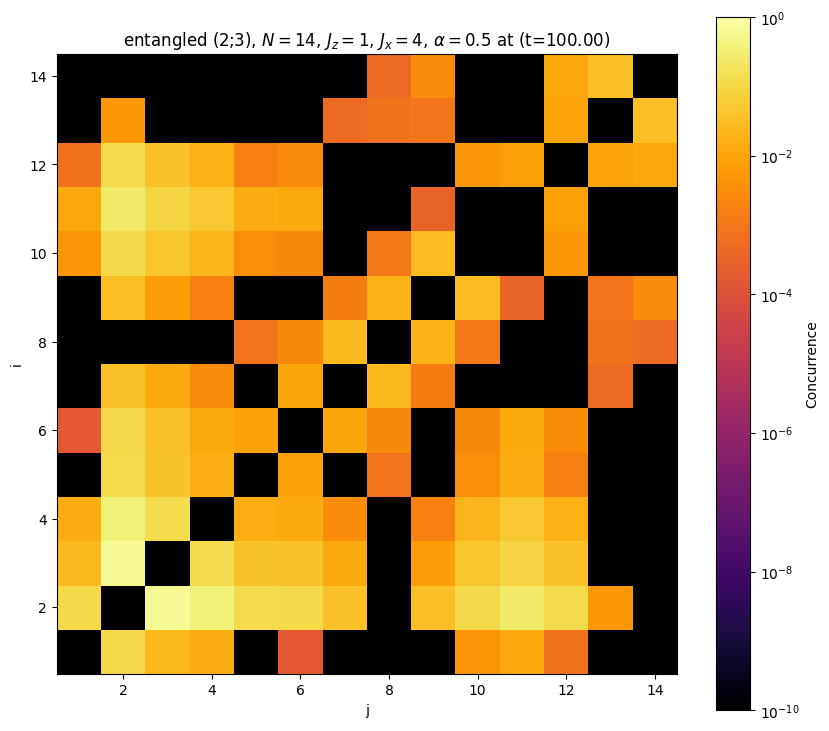

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as colors   # <-- you need this

outdir="ED_Data/Cij"
prefix="LRb1"

# -----------------------------
# load the Cij matrix CSV
# -----------------------------
csv_path = f"{outdir}/{prefix}conc.csv"  # <-- adjust filename to yours
df = pd.read_csv(csv_path)

# restrict time window if you want (same as you did)
df = df[(df["t"] >= 0.0) & (df["t"] <= 100.0)].copy()

times = df["t"].values
N=14
ns = N

# -----------------------------
# plotting setup (your style)
# -----------------------------
vmin = 1e-10
vmax = 1.0

fig, ax = plt.subplots(figsize=(10, 9))

C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# -----------------------------
# minimal: precompute column lookup
# -----------------------------
col = {(i, j): f"C_{i}_{j}" for i in range(ns) for j in range(ns)}

# -----------------------------
# update frame
# -----------------------------
def update(frame):
    row = df.iloc[frame]
    C = np.full((ns, ns), np.nan)

    for i in range(ns):
        for j in range(ns):
            val = row[col[(i, j)]]
            # LogNorm can't take 0 -> clamp
            if val <= 0:
                val = vmin
            C[i, j] = val

    im.set_data(C)
    title.set_text(rf"entangled (2;3), $N={N}$, $J_z=1$, $J_x=4$, $\alpha=0.5$ at (t={row['t']:.2f})")
    return (im,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(df),
    interval=60,
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("gif/conc_LRb1.gif", writer=PillowWriter(fps=5))


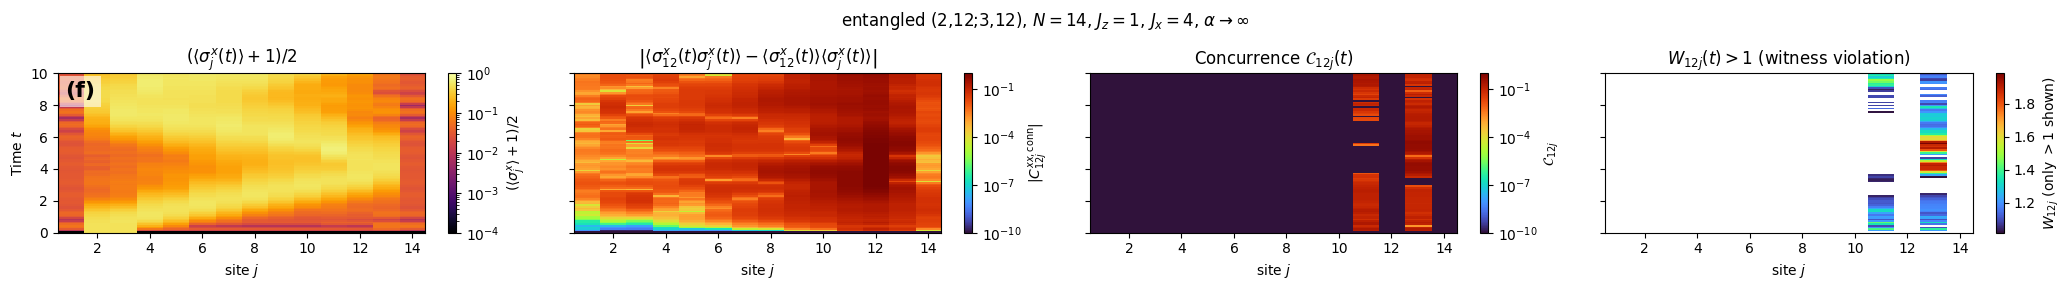

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 11            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="EDNNb12"

panel_letter = "(f)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.01, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_{12}^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_{12}^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{12j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{12j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{12j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{12j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{12j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDNNb12.pdf")
plt.show()


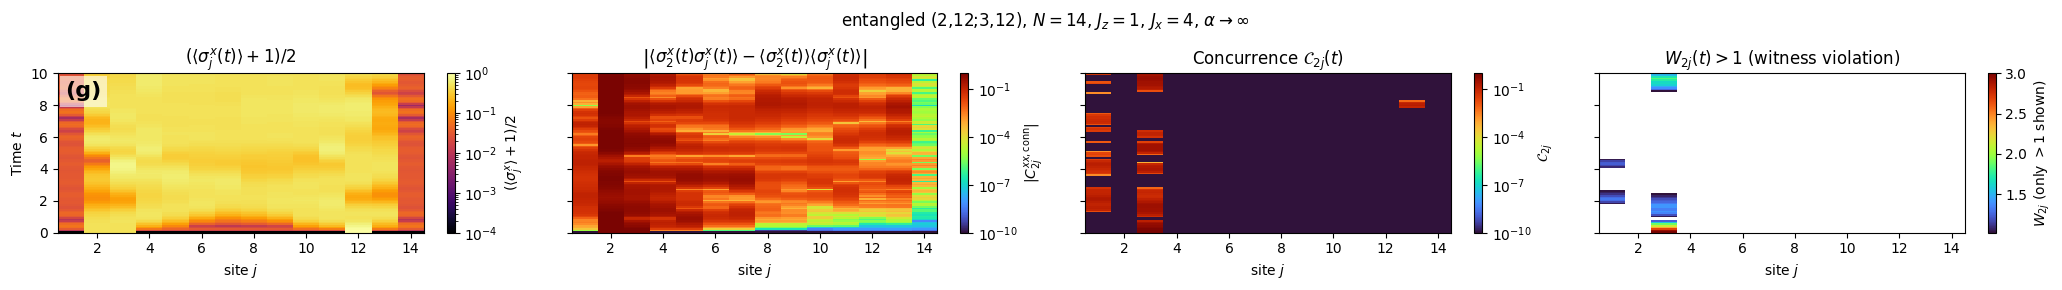

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="NNb2"

panel_letter = "(g)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDNNb2.pdf")
plt.show()


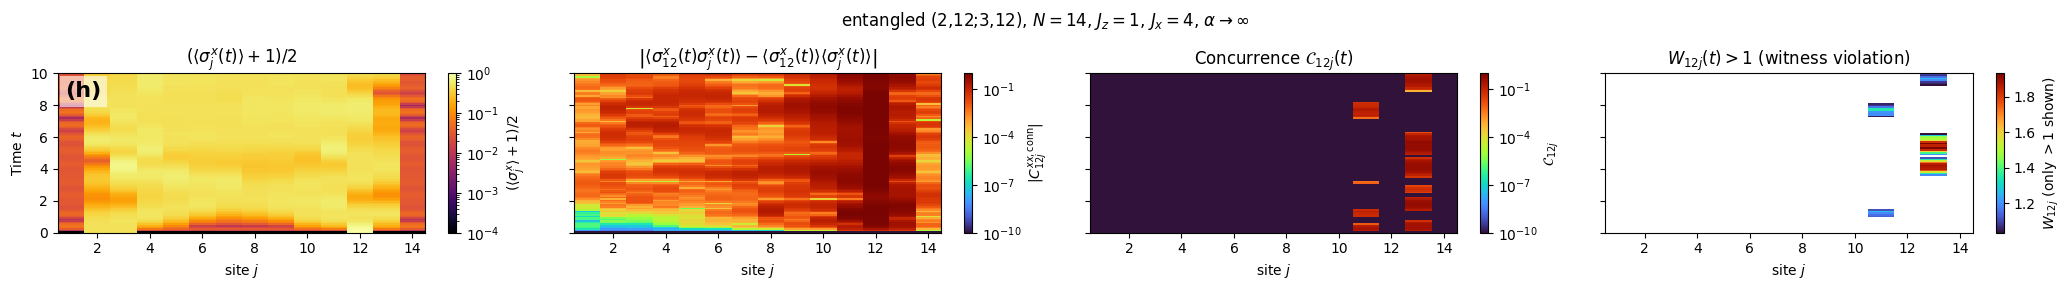

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 11            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="NNb22"

panel_letter = "(h)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.01, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_{12}^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_{12}^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{12j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{12j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{12j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{12j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{12j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDNNb22.pdf")
plt.show()


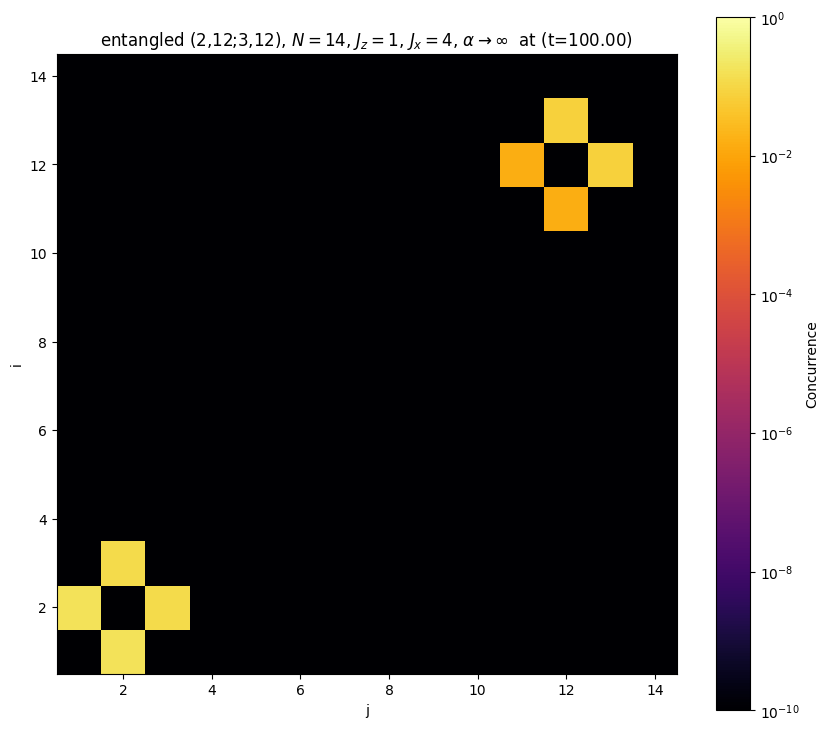

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as colors   # <-- you need this

outdir="ED_Data/Cij"
prefix="NNb2"

# -----------------------------
# load the Cij matrix CSV
# -----------------------------
csv_path = f"{outdir}/{prefix}conc.csv"  # <-- adjust filename to yours
df = pd.read_csv(csv_path)

# restrict time window if you want (same as you did)
df = df[(df["t"] >= 0.0) & (df["t"] <= 100.0)].copy()

times = df["t"].values
N=14
ns = N

# -----------------------------
# plotting setup (your style)
# -----------------------------
vmin = 1e-10
vmax = 1.0

fig, ax = plt.subplots(figsize=(10, 9))

C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# -----------------------------
# minimal: precompute column lookup
# -----------------------------
col = {(i, j): f"C_{i}_{j}" for i in range(ns) for j in range(ns)}

# -----------------------------
# update frame
# -----------------------------
def update(frame):
    row = df.iloc[frame]
    C = np.full((ns, ns), np.nan)

    for i in range(ns):
        for j in range(ns):
            val = row[col[(i, j)]]
            # LogNorm can't take 0 -> clamp
            if val <= 0:
                val = vmin
            C[i, j] = val

    im.set_data(C)
    title.set_text(rf"entangled (2,12;3,12), $N={N}$, $J_z=1$, $J_x=4$, $\alpha\to\infty$  at (t={row['t']:.2f})")
    return (im,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(df),
    interval=60,
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("gif/conc_NNb2.gif", writer=PillowWriter(fps=5))


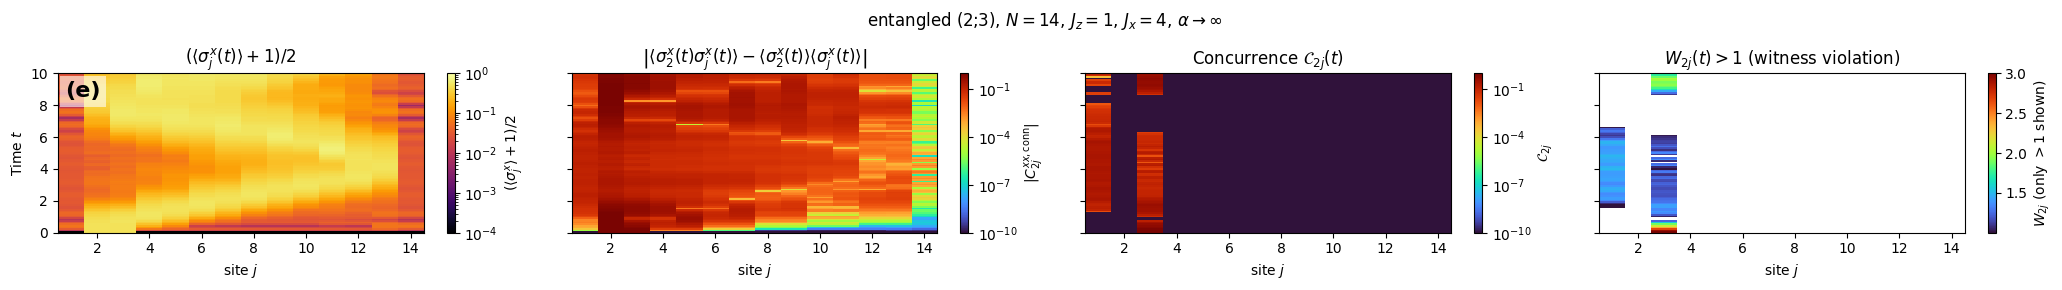

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 10
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/C2j"
prefix="NNb1"

panel_letter = "(e)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magx.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mx_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2;3), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=0.95)

plt.tight_layout()
plt.savefig("plt/EDNNb1.pdf")
plt.show()


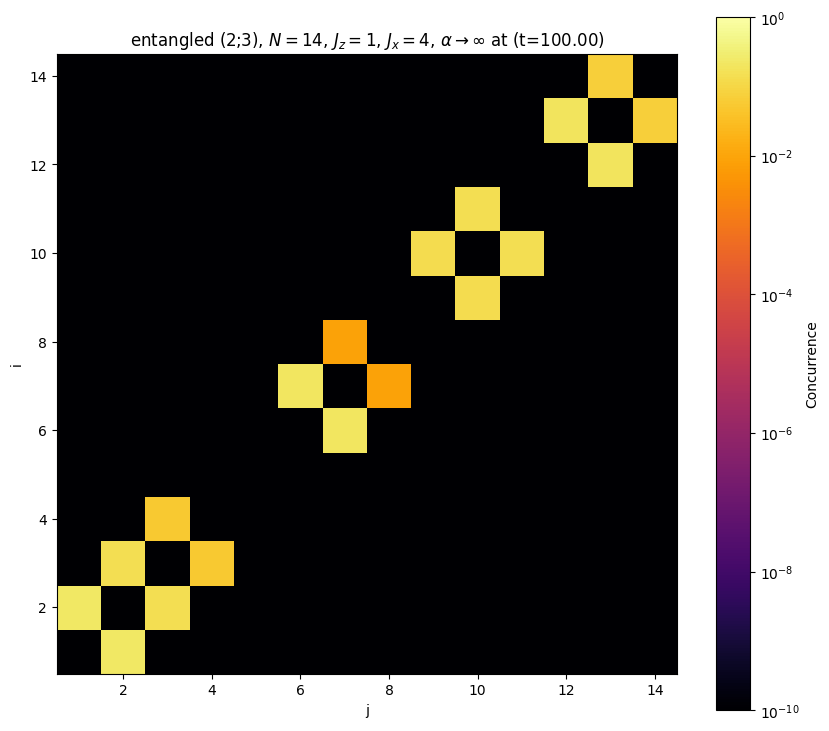

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as colors   # <-- you need this

outdir="ED_Data/Cij"
prefix="NNb1"

# -----------------------------
# load the Cij matrix CSV
# -----------------------------
csv_path = f"{outdir}/{prefix}conc.csv"  # <-- adjust filename to yours
df = pd.read_csv(csv_path)

# restrict time window if you want (same as you did)
df = df[(df["t"] >= 0.0) & (df["t"] <= 100.0)].copy()

times = df["t"].values
N=14
ns = N

# -----------------------------
# plotting setup (your style)
# -----------------------------
vmin = 1e-10
vmax = 1.0

fig, ax = plt.subplots(figsize=(10, 9))

C0 = np.full((ns, ns), np.nan)

cmap = plt.cm.inferno.copy()
cmap.set_under("black")

im = ax.imshow(
    C0,
    origin="lower",
    cmap=cmap,
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    extent=[0.5, ns+0.5, 0.5, ns+0.5],
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Concurrence")

ticks = np.arange(2, ns+1, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("j")
ax.set_ylabel("i")

title = ax.set_title("")

# -----------------------------
# minimal: precompute column lookup
# -----------------------------
col = {(i, j): f"C_{i}_{j}" for i in range(ns) for j in range(ns)}

# -----------------------------
# update frame
# -----------------------------
def update(frame):
    row = df.iloc[frame]
    C = np.full((ns, ns), np.nan)

    for i in range(ns):
        for j in range(ns):
            val = row[col[(i, j)]]
            # LogNorm can't take 0 -> clamp
            if val <= 0:
                val = vmin
            C[i, j] = val

    im.set_data(C)
    title.set_text(rf"entangled (2;3), $N={N}$, $J_z=1$, $J_x=4$, $\alpha\to\infty$ at (t={row['t']:.2f})")
    return (im,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(df),
    interval=60,
    blit=True
)

from matplotlib.animation import PillowWriter
ani.save("gif/conc_NNb1.gif", writer=PillowWriter(fps=5))


## Projected Dynamics

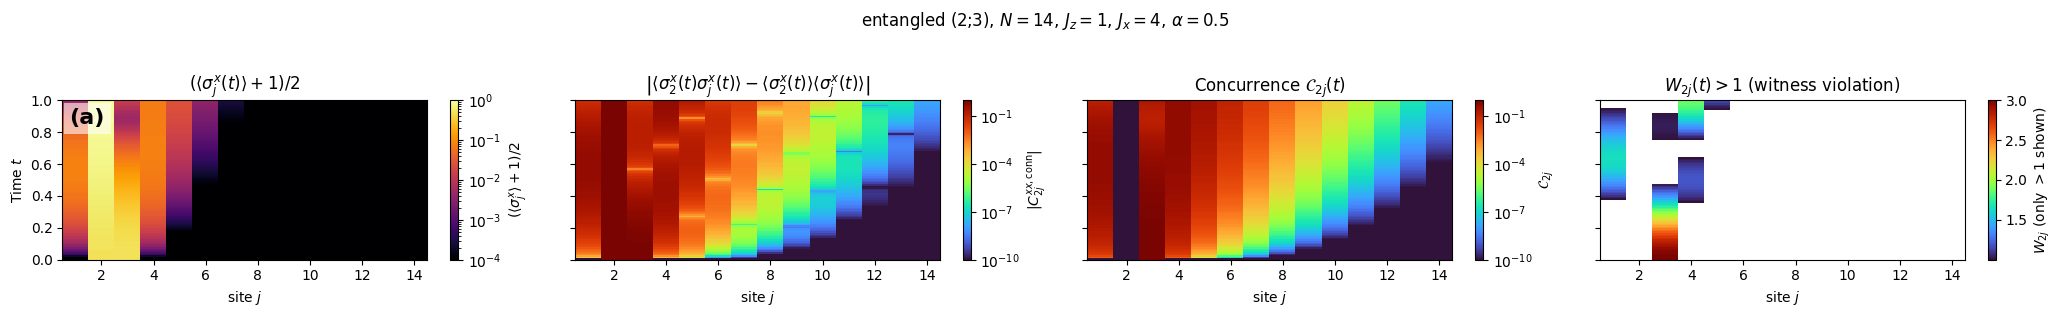

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 1
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/Projected"
prefix="LRb1"

panel_letter = "(a)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magz.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corr.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mz_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Cxx_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2;3), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=1.04)

plt.tight_layout()
# plt.savefig("plt/ED1.pdf")
plt.show()


Detected N=14 concurrence columns for p=1: C_1_0 ... C_1_13
Requested t=0.05, using t=0.05 (row 5)
  fit j in [4,14]:  n=1.397, k=1.479, A=1466, npts=6
Requested t=0.1, using t=0.1 (row 10)
  fit j in [4,14]:  n=1.444, k=1.098, A=355.5, npts=7
Requested t=0.2, using t=0.2 (row 20)
  fit j in [4,14]:  n=1.515, k=0.7413, A=90.8, npts=8
Requested t=0.5, using t=0.5 (row 50)
  fit j in [4,14]:  n=1.655, k=0.3561, A=17.74, npts=11
Requested t=0.8, using t=0.8 (row 80)
  fit j in [4,14]:  n=1.89, k=0.1486, A=4.827, npts=11
Requested t=1.0, using t=1.0 (row 100)
  fit j in [4,14]:  n=2.062, k=0.08184, A=2.58, npts=11


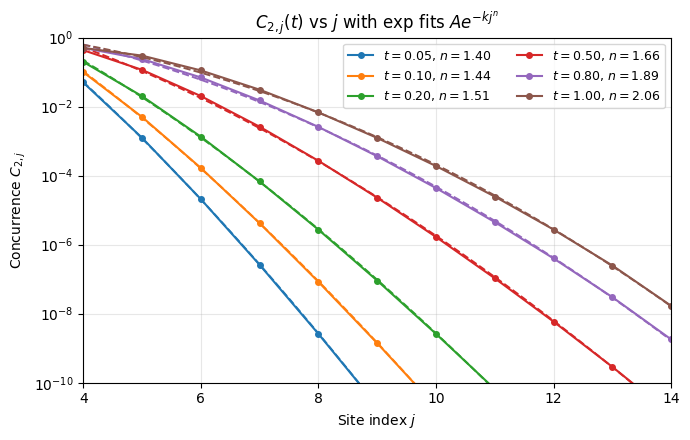

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fit_stretched_exponential(j, C, n_min=0.1, n_max=4.0, n_steps=400):
    """
    Fit C(j) ≈ A * exp(-k * j^n) on a semilogy plot.
    Uses grid search over n, and for each n fits log C = b - k * (j^n) by linear regression.

    Returns: (A, k, n_best)
    """
    j = np.asarray(j, dtype=float)
    C = np.asarray(C, dtype=float)

    y = np.log(C)
    n_grid = np.linspace(n_min, n_max, n_steps)

    best = None  # (sse, A, k, n)
    for n in n_grid:
        x = j**n
        # linear fit: y = m x + b  (we expect m = -k)
        m, b = np.polyfit(x, y, 1)
        yhat = m * x + b
        sse = np.sum((y - yhat)**2)

        k = -m
        A = np.exp(b)

        if best is None or sse < best[0]:
            best = (sse, A, k, n)

    _, A_best, k_best, n_best = best
    return A_best, k_best, n_best

# -----------------------------
# SETTINGS
# -----------------------------
p_target = 1
times_to_plot = [0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
df = df_conc

C_floor = 1e-16
tol = 1e-16

# Fit window in j (1-based)
j_fit_min = 4
j_fit_max = 14   # or N later

# -----------------------------
# LOAD COLUMNS
# -----------------------------
t_all = df["t"].values

c_cols = [c for c in df.columns if c.startswith(f"C_{p_target}_")]
if len(c_cols) == 0:
    raise RuntimeError(f"No columns found like C_{p_target}_* in file.")

def j_from_col(col):
    return int(col.split("_")[-1])  # "C_1_13" -> 13

c_cols = sorted(c_cols, key=j_from_col)
N = len(c_cols)
print(f"Detected N={N} concurrence columns for p={p_target}: {c_cols[0]} ... {c_cols[-1]}")

j_plot = np.arange(N) + 1  # 1-based x-axis
# -----------------------------
# PLOT + STRETCHED-EXP FITS
# -----------------------------
plt.figure(figsize=(7, 4.5))

for t_query in times_to_plot:
    idx = int(np.argmin(np.abs(t_all - t_query)))
    t_used = float(t_all[idx])
    print(f"Requested t={t_query}, using t={t_used} (row {idx})")

    C_vals = df.loc[idx, c_cols].to_numpy(dtype=float)
    C_vals = np.maximum(C_vals, C_floor)

    fit_mask = (
        (j_plot >= j_fit_min) &
        (j_plot <= min(j_fit_max, N)) &
        np.isfinite(C_vals) &
        (C_vals > C_floor)
    )

    # plot data
    line, = plt.semilogy(
        j_plot, C_vals,
        "o-", lw=1.5, ms=4,
        label=rf"$t={t_used:.2f}$"
    )

    if np.count_nonzero(fit_mask) >= 3:
        j_fit = j_plot[fit_mask]
        C_fit = C_vals[fit_mask]

        A, k, n_pow = fit_stretched_exponential(j_fit, C_fit, n_min=0.1, n_max=4.0, n_steps=500)

        # update legend: display n (and optionally k too)
        line.set_label(rf"$t={t_used:.2f}$, $n={n_pow:.2f}$")

        # overlay fit on full plotted range (or just the fit window—your choice)
        jj = np.linspace(j_fit_min, min(j_fit_max, N), 250)
        CC = A * np.exp(-k * (jj**n_pow))
        plt.semilogy(jj, CC, "--", lw=1.4, color=line.get_color())

        print(f"  fit j in [{j_fit_min},{min(j_fit_max,N)}]:  n={n_pow:.4g}, k={k:.4g}, A={A:.4g}, npts={len(j_fit)}")
    else:
        print(f"  fit skipped: need >=3 points in [{j_fit_min},{min(j_fit_max,N)}] above floor")

plt.xlabel("Site index $j$")
plt.ylabel(rf"Concurrence $C_{{{p_target+1},j}}$")
plt.title(rf"$C_{{{p_target+1},j}}(t)$ vs $j$ with exp fits $A e^{{-k j^n}}$")
plt.grid(True, which="both", alpha=0.3)
plt.xlim(j_fit_min, N)
plt.ylim(1e-10, 1)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("plt/c2j_vs_j_exp.pdf", dpi=600)
plt.show()


Detected N=14 columns for p=1: C_1_0 ... C_1_13


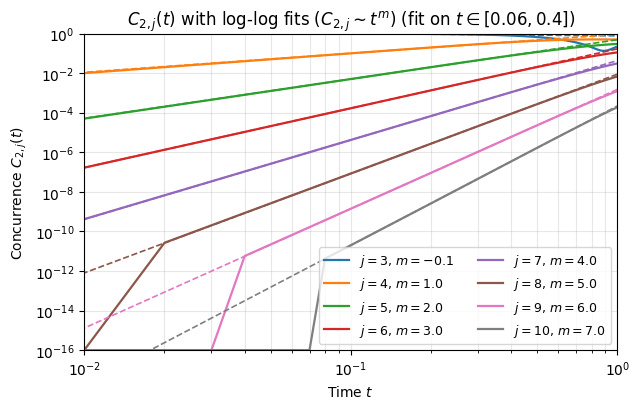

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def fit_powerlaw_loglog(t, y):
    """
    Fit y ~ A * t^m on log-log axes.
    Returns (m, A).
    """
    x = np.log10(t)
    z = np.log10(y)
    m, b = np.polyfit(x, z, 1)   # z = m x + b
    A = 10**b
    return m, A

# -----------------------------
# SETTINGS
# -----------------------------
df = df_conc               # <-- your dataframe
p_target = 1               # columns: C_1_0 ... C_1_{N-1}
j_sites_to_plot = [2,3,4,5,6,7,8,9]   # FILE indexing (0-based j)
C_floor = 1e-16

t0, t1 = 0.06, 0.40        # fit window in time

# -----------------------------
# LOAD DATA
# -----------------------------
t_list = df["t"].to_numpy(dtype=float)

# get concurrence columns for this p_target
c_cols = [c for c in df.columns if c.startswith(f"C_{p_target}_")]
if len(c_cols) == 0:
    raise RuntimeError(f"No columns found like C_{p_target}_* in df.")

def j_from_col(col):
    # "C_1_13" -> 13
    return int(col.split("_")[-1])

c_cols = sorted(c_cols, key=j_from_col)
N = len(c_cols)
print(f"Detected N={N} columns for p={p_target}: {c_cols[0]} ... {c_cols[-1]}")

# mask for fit window (same for all j)
mask_t = (t_list >= t0) & (t_list <= t1) & np.isfinite(t_list)
if np.count_nonzero(mask_t) < 2:
    raise RuntimeError("Not enough time points in the chosen fit window [t0, t1].")

# -----------------------------
# PLOT: curves + fits
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.2))

for j_target in j_sites_to_plot:
    if j_target < 0 or j_target >= N:
        print(f"Warning: j={j_target} out of range for N={N}, skipping.")
        continue

    col = f"C_{p_target}_{j_target}"
    if col not in df.columns:
        print(f"Warning: missing column {col}, skipping.")
        continue

    C = df[col].to_numpy(dtype=float)
    C = np.maximum(C, C_floor)

    # raw data curve
    line, = ax.loglog(t_list, C, "-", lw=1.6, label=rf"$j={j_target+1}$")

    # fit only where both t and C are valid
    mask = mask_t & np.isfinite(C) & (C > C_floor)
    if np.count_nonzero(mask) >= 2:
        t_fit = t_list[mask]
        C_fit = C[mask]

        m, A = fit_powerlaw_loglog(t_fit, C_fit)

        # extrapolate fit (choose the t-range you want to display)
        tt = np.logspace(np.log10(max(t_list.min(), 1e-12)), np.log10(t_list.max()), 300)
        ax.loglog(tt, A * tt**m, "--", lw=1.2, color=line.get_color())

        # show slope in legend
        line.set_label(rf"$j={j_target+1}$, $m={m:.1f}$")
    else:
        print(f"Fit skipped for j={j_target}: not enough points above floor in [{t0},{t1}]")

# cosmetics
ax.set_xlabel("Time $t$")
ax.set_ylabel(rf"Concurrence $C_{{{p_target+1},j}}(t)$")
ax.set_title(
    rf"$C_{{{p_target+1},j}}(t)$ with log-log fits ($C_{{{p_target+1},j}}\sim t^{{m}}$) "
    rf"(fit on $t\in[{t0},{t1}]$)"
)
ax.grid(True, which="both", alpha=0.3)

# safe xlim for log scale
ax.set_xlim(1e-2, t_list.max())
ax.set_ylim(C_floor, 1.0)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig("plt/c2j_vs_t.pdf", dpi=600)
plt.show()


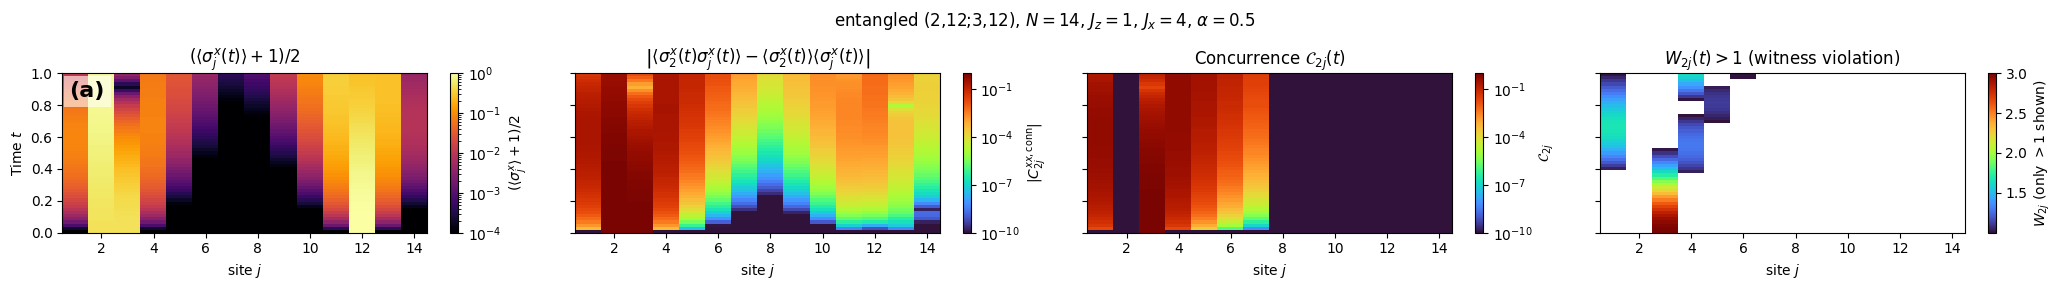

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# SETTINGS
# -------------------------
i0 = 1            # python index for "site 2" in the paper
t_max_plot = 1
alpha=0.5
N=14
Jz=1
Jx=4

vmin_mz   = 1e-4
vmin_corr = 1e-10
vmin_conc = 1e-10
vmin_wit  = 1e-10

outdir="ED_Data/Projected"
prefix="LRb2"

panel_letter = "(a)"

# -------------------------
# LOAD DATA
# -------------------------
df_mz   = pd.read_csv(f"{outdir}/{prefix}magz.csv")
# NOTE: use the file your simulator actually wrote
# If you saved connected-xx as "correlations_xx_connected.csv", use that:
try:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corrzz.csv")
except FileNotFoundError:
    df_corr = pd.read_csv(f"{outdir}/{prefix}corrzz.csv")

df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

# -------------------------
# TIME AXIS (MASTER)
# -------------------------
t = df_mz["t"].values
mask = t <= t_max_plot
t_plot = t[mask]
t_min, t_max = t_plot.min(), t_plot.max()

# -------------------------
# MAGNETIZATION
# -------------------------
mz_cols = [c for c in df_mz.columns if c.startswith("mz_")]
mz = df_mz[mz_cols].values
mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
mz = np.clip(mz, vmin_mz, 1.0)
mz_plot = mz[mask, :]

# -------------------------
# CONNECTED CORRELATIONS C_{2j}^{xx,conn}
# -------------------------
C_cols = [c for c in df_corr.columns if c.startswith(f"Czz_{i0}_")]
j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
order = np.argsort(j_vals)

CorrMat = np.abs(df_corr[C_cols].values[:, order])
CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
CorrMat = CorrMat[mask, :]

# -------------------------
# CONCURRENCE C_{2j}
# -------------------------
ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
# Keep only the same j's used in CorrMat (so columns align)
ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
ConMat = df_conc[ConCols].values
ConMat = np.clip(ConMat, vmin_conc, 1.0)
ConMat = ConMat[mask, :]

# -------------------------
# WITNESS  W_{2j}(t)
# -------------------------
W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

WMat_raw = df_wit[W_cols].values
WMat_raw = WMat_raw[mask, :]

# Mask everything that does NOT violate the bound
WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

# x-axis corresponds to site index j (0..N-1) laid out as image columns
extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

# (1) Magnetization
im0 = ax[0].imshow(
    mz_plot,
    origin="lower",
    aspect="auto",
    cmap="inferno",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
    extent=extent,
)
ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
ax[0].set_ylabel(r"Time $t$")
ax[0].set_xlabel(r"site $j$")

# (2) Connected correlations
im1 = ax[1].imshow(
    CorrMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
    extent=extent,
)
ax[1].set_title(
    r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
    r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
)
ax[1].set_xlabel(r"site $j$")

# (3) Concurrence
im2 = ax[2].imshow(
    ConMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
    extent=extent,
)
ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
ax[2].set_xlabel(r"site $j$")

# (4) Witness
# Witness can be >1, so use linear norm or log with vmax=WMat.max()
# Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
wit_vmax = float(np.nanmax(WMat))
im3 = ax[3].imshow(
    WMat,
    origin="lower",
    aspect="auto",
    cmap="turbo",
    interpolation="nearest",
    extent=extent,
)

ax[3].set_title(
    r"$W_{2j}(t)>1$ (witness violation)"
)
ax[3].set_xlabel(r"site $j$")


# Colorbars
plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


# Panel letter
ax[0].text(
    0.02, 0.95, panel_letter,
    transform=ax[0].transAxes,
    fontsize=16, fontweight="bold",
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
if alpha >= 100:
    plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
else:
    plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=0.95)

plt.tight_layout()
plt.savefig("plt/ProjectedLRb2.pdf")
plt.show()


Detected N=14 concurrence columns for p=1: C_1_0 ... C_1_13
Requested t=0.05, using t=0.06 (row 3)
  fit j in [4,14]:  n=1.499, k=1.109, A=422.1, npts=4
Requested t=0.1, using t=0.1 (row 5)
  fit j in [4,14]:  n=1.577, k=0.801, A=125.3, npts=4
Requested t=0.2, using t=0.2 (row 10)
  fit j in [4,14]:  n=1.757, k=0.4199, A=24.04, npts=4
Requested t=0.5, using t=0.5 (row 25)
  fit j in [4,14]:  n=2.32, k=0.07813, A=3.064, npts=4
Requested t=0.8, using t=0.8 (row 40)
  fit j in [4,14]:  n=3.179, k=0.008834, A=1.064, npts=4
Requested t=1.0, using t=1.0 (row 50)
  fit j in [4,14]:  n=4, k=0.001295, A=0.6889, npts=4


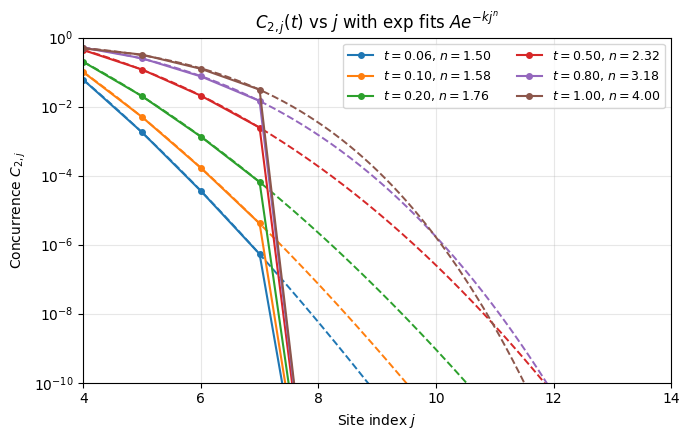

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def fit_stretched_exponential(j, C, n_min=0.1, n_max=4.0, n_steps=400):
    """
    Fit C(j) ≈ A * exp(-k * j^n) on a semilogy plot.
    Uses grid search over n, and for each n fits log C = b - k * (j^n) by linear regression.

    Returns: (A, k, n_best)
    """
    j = np.asarray(j, dtype=float)
    C = np.asarray(C, dtype=float)

    y = np.log(C)
    n_grid = np.linspace(n_min, n_max, n_steps)

    best = None  # (sse, A, k, n)
    for n in n_grid:
        x = j**n
        # linear fit: y = m x + b  (we expect m = -k)
        m, b = np.polyfit(x, y, 1)
        yhat = m * x + b
        sse = np.sum((y - yhat)**2)

        k = -m
        A = np.exp(b)

        if best is None or sse < best[0]:
            best = (sse, A, k, n)

    _, A_best, k_best, n_best = best
    return A_best, k_best, n_best

# -----------------------------
# SETTINGS
# -----------------------------
p_target = 1
times_to_plot = [0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
df = df_conc

C_floor = 1e-16
tol = 1e-16

# Fit window in j (1-based)
j_fit_min = 4
j_fit_max = 14   # or N later

# -----------------------------
# LOAD COLUMNS
# -----------------------------
t_all = df["t"].values

c_cols = [c for c in df.columns if c.startswith(f"C_{p_target}_")]
if len(c_cols) == 0:
    raise RuntimeError(f"No columns found like C_{p_target}_* in file.")

def j_from_col(col):
    return int(col.split("_")[-1])  # "C_1_13" -> 13

c_cols = sorted(c_cols, key=j_from_col)
N = len(c_cols)
print(f"Detected N={N} concurrence columns for p={p_target}: {c_cols[0]} ... {c_cols[-1]}")

j_plot = np.arange(N) + 1  # 1-based x-axis

# -----------------------------
# PLOT + STRETCHED-EXP FITS
# -----------------------------
plt.figure(figsize=(7, 4.5))

for t_query in times_to_plot:
    idx = int(np.argmin(np.abs(t_all - t_query)))
    t_used = float(t_all[idx])
    print(f"Requested t={t_query}, using t={t_used} (row {idx})")

    C_vals = df.loc[idx, c_cols].to_numpy(dtype=float)
    C_vals = np.maximum(C_vals, C_floor)

    fit_mask = (
        (j_plot >= j_fit_min) &
        (j_plot <= min(j_fit_max, N)) &
        np.isfinite(C_vals) &
        (C_vals > C_floor)
    )

    # plot data
    line, = plt.semilogy(
        j_plot, C_vals,
        "o-", lw=1.5, ms=4,
        label=rf"$t={t_used:.2f}$"
    )

    if np.count_nonzero(fit_mask) >= 3:
        j_fit = j_plot[fit_mask]
        C_fit = C_vals[fit_mask]

        A, k, n_pow = fit_stretched_exponential(j_fit, C_fit, n_min=0.1, n_max=4.0, n_steps=500)

        # update legend: display n (and optionally k too)
        line.set_label(rf"$t={t_used:.2f}$, $n={n_pow:.2f}$")

        # overlay fit on full plotted range (or just the fit window—your choice)
        jj = np.linspace(j_fit_min, min(j_fit_max, N), 250)
        CC = A * np.exp(-k * (jj**n_pow))
        plt.semilogy(jj, CC, "--", lw=1.4, color=line.get_color())

        print(f"  fit j in [{j_fit_min},{min(j_fit_max,N)}]:  n={n_pow:.4g}, k={k:.4g}, A={A:.4g}, npts={len(j_fit)}")
    else:
        print(f"  fit skipped: need >=3 points in [{j_fit_min},{min(j_fit_max,N)}] above floor")

plt.xlabel("Site index $j$")
plt.ylabel(rf"Concurrence $C_{{{p_target+1},j}}$")
plt.title(rf"$C_{{{p_target+1},j}}(t)$ vs $j$ with exp fits $A e^{{-k j^n}}$")
plt.grid(True, which="both", alpha=0.3)
plt.xlim(j_fit_min, N)
plt.ylim(1e-10, 1)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("plt/c2j_vs_j_exp.pdf", dpi=600)
plt.show()


Detected N=14 columns for p=1: C_1_0 ... C_1_13


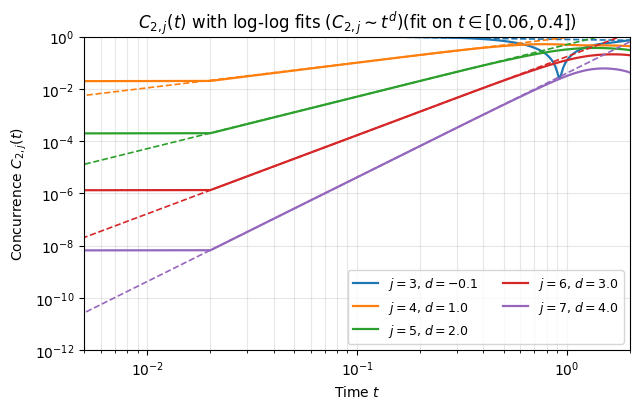

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def fit_powerlaw_loglog(t, y):
    """
    Fit y ~ A * t^m on log-log axes.
    Returns (m, A).
    """
    x = np.log10(t)
    z = np.log10(y)
    m, b = np.polyfit(x, z, 1)   # z = m x + b
    A = 10**b
    return m, A

# -----------------------------
# SETTINGS
# -----------------------------
df = df_conc               # <-- your dataframe
p_target = 1               # columns: C_1_0 ... C_1_{N-1}
j_sites_to_plot = [2,3,4,5,6]   # FILE indexing (0-based j)
C_floor = 1e-16

t0, t1 = 0.06, 0.40        # fit window in time

# -----------------------------
# LOAD DATA
# -----------------------------
t_list = df["t"].to_numpy(dtype=float)

# get concurrence columns for this p_target
c_cols = [c for c in df.columns if c.startswith(f"C_{p_target}_")]
if len(c_cols) == 0:
    raise RuntimeError(f"No columns found like C_{p_target}_* in df.")

def j_from_col(col):
    # "C_1_13" -> 13
    return int(col.split("_")[-1])

c_cols = sorted(c_cols, key=j_from_col)
N = len(c_cols)
print(f"Detected N={N} columns for p={p_target}: {c_cols[0]} ... {c_cols[-1]}")

# mask for fit window (same for all j)
mask_t = (t_list >= t0) & (t_list <= t1) & np.isfinite(t_list)
if np.count_nonzero(mask_t) < 2:
    raise RuntimeError("Not enough time points in the chosen fit window [t0, t1].")

# -----------------------------
# PLOT: curves + fits
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.2))

for j_target in j_sites_to_plot:
    if j_target < 0 or j_target >= N:
        print(f"Warning: j={j_target} out of range for N={N}, skipping.")
        continue

    col = f"C_{p_target}_{j_target}"
    if col not in df.columns:
        print(f"Warning: missing column {col}, skipping.")
        continue

    C = df[col].to_numpy(dtype=float)
    C = np.maximum(C, C_floor)

    # raw data curve
    line, = ax.loglog(t_list, C, "-", lw=1.6, label=rf"$j={j_target+1}$")

    # fit only where both t and C are valid
    mask = mask_t & np.isfinite(C) & (C > C_floor)
    if np.count_nonzero(mask) >= 2:
        t_fit = t_list[mask]
        C_fit = C[mask]

        m, A = fit_powerlaw_loglog(t_fit, C_fit)

        # extrapolate fit (choose the t-range you want to display)
        tt = np.logspace(np.log10(max(t_list.min(), 1e-12)), np.log10(t_list.max()), 300)
        ax.loglog(tt, A * tt**m, "--", lw=1.2, color=line.get_color())

        # show slope in legend
        line.set_label(rf"$j={j_target+1}$, $d={m:.1f}$")
    else:
        print(f"Fit skipped for j={j_target}: not enough points above floor in [{t0},{t1}]")

# cosmetics
ax.set_xlabel("Time $t$")
ax.set_ylabel(rf"Concurrence $C_{{{p_target+1},j}}(t)$")
ax.set_title(
    rf"$C_{{{p_target+1},j}}(t)$ with log-log fits ($C_{{{p_target+1},j}}\sim t^{{d}}$)"
    rf"(fit on $t\in[{t0},{t1}]$)"
)
ax.grid(True, which="both", alpha=0.3)

# safe xlim for log scale
ax.set_xlim(5e-3, t_list.max())
ax.set_ylim(1e-12, 1.0)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig("plt/c2j_vs_t.pdf", dpi=600)
plt.show()

## Varying Jz/Jx

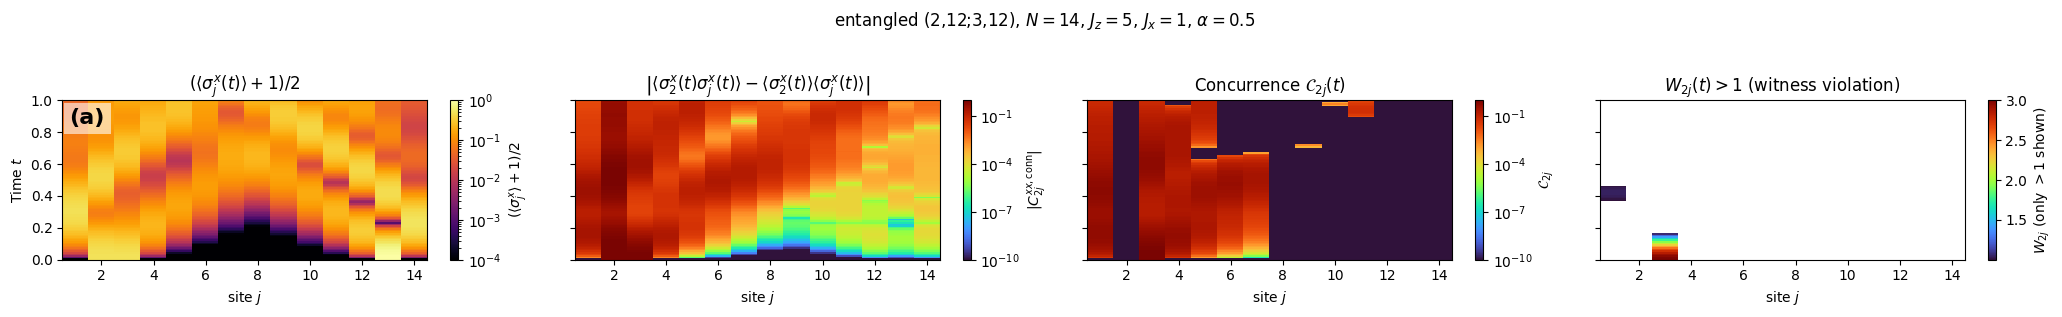

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

JzValues=[5]
for Jz in JzValues:
        
    # -------------------------
    # SETTINGS
    # -------------------------
    i0 = 1            # python index for "site 2" in the paper
    t_max_plot = 2
    alpha=0.5
    N=14
    # Jz=1
    Jx=1

    vmin_mz   = 1e-4
    vmin_corr = 1e-10
    vmin_conc = 1e-10
    vmin_wit  = 1e-10

    outdir="ED_Data/ProjectedJzSweep"
    prefix=f"LRb1{Jz*10:.0f}"

    panel_letter = "(a)"

    # -------------------------
    # LOAD DATA
    # -------------------------
    df_mz   = pd.read_csv(f"{outdir}/{prefix}magz.csv")
    # NOTE: use the file your simulator actually wrote
    # If you saved connected-xx as "correlations_xx_connected.csv", use that:
    try:
        df_corr = pd.read_csv(f"{outdir}/{prefix}corrzz.csv")
    except FileNotFoundError:
        df_corr = pd.read_csv(f"{outdir}/{prefix}corrzz.csv")

    df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")
    df_wit  = pd.read_csv(f"{outdir}/{prefix}wit.csv")  # witness_W output

    # -------------------------
    # TIME AXIS (MASTER)
    # -------------------------
    t = df_mz["t"].values
    mask = t <= t_max_plot
    t_plot = t[mask]
    t_min, t_max = t_plot.min(), t_plot.max()

    # -------------------------
    # MAGNETIZATION
    # -------------------------
    mz_cols = [c for c in df_mz.columns if c.startswith("mz_")]
    mz = df_mz[mz_cols].values
    mz = (mz + 1) / 2                      # normalize [-1,1] → [0,1]
    mz = np.clip(mz, vmin_mz, 1.0)
    mz_plot = mz[mask, :]

    # -------------------------
    # CONNECTED CORRELATIONS C_{2j}^{xx,conn}
    # -------------------------
    C_cols = [c for c in df_corr.columns if c.startswith(f"Czz_{i0}_")]
    j_vals = np.array([int(c.split("_")[-1]) for c in C_cols])
    order = np.argsort(j_vals)

    CorrMat = np.abs(df_corr[C_cols].values[:, order])
    CorrMat = np.clip(CorrMat, vmin_corr, 1.0)
    CorrMat = CorrMat[mask, :]

    # -------------------------
    # CONCURRENCE C_{2j}
    # -------------------------
    ConCols = [c for c in df_conc.columns if c.startswith(f"C_{i0}_")]
    # Keep only the same j's used in CorrMat (so columns align)
    ConCols = [f"C_{i0}_{j}" for j in j_vals[order] if f"C_{i0}_{j}" in df_conc.columns]
    ConMat = df_conc[ConCols].values
    ConMat = np.clip(ConMat, vmin_conc, 1.0)
    ConMat = ConMat[mask, :]

    # -------------------------
    # WITNESS  W_{2j}(t)
    # -------------------------
    W_cols = [c for c in df_wit.columns if c.startswith(f"W_{i0}_")]
    W_cols = [f"W_{i0}_{j}" for j in j_vals[order] if f"W_{i0}_{j}" in df_wit.columns]

    WMat_raw = df_wit[W_cols].values
    WMat_raw = WMat_raw[mask, :]

    # Mask everything that does NOT violate the bound
    WMat = np.ma.masked_where(WMat_raw <= 1.0, WMat_raw)


    # -------------------------
    # PLOT
    # -------------------------
    fig, ax = plt.subplots(1, 4, figsize=(21, 3), sharey=True)

    # x-axis corresponds to site index j (0..N-1) laid out as image columns
    extent = [0.5, CorrMat.shape[1] + 0.5, t_min, t_max]

    # (1) Magnetization
    im0 = ax[0].imshow(
        mz_plot,
        origin="lower",
        aspect="auto",
        cmap="inferno",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=vmin_mz, vmax=1),
        extent=extent,
    )
    ax[0].set_title(r"$(\langle \sigma^x_j(t)\rangle + 1)/2$")
    ax[0].set_ylabel(r"Time $t$")
    ax[0].set_xlabel(r"site $j$")

    # (2) Connected correlations
    im1 = ax[1].imshow(
        CorrMat,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=vmin_corr, vmax=1),
        extent=extent,
    )
    ax[1].set_title(
        r"$\left|\langle \sigma_2^x(t)\sigma_j^x(t)\rangle"
        r"-\langle \sigma_2^x(t)\rangle\langle \sigma_j^x(t)\rangle\right|$"
    )
    ax[1].set_xlabel(r"site $j$")

    # (3) Concurrence
    im2 = ax[2].imshow(
        ConMat,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=vmin_conc, vmax=1),
        extent=extent,
    )
    ax[2].set_title(r"Concurrence $\mathcal{C}_{2j}(t)$")
    ax[2].set_xlabel(r"site $j$")

    # (4) Witness
    # Witness can be >1, so use linear norm or log with vmax=WMat.max()
    # Here: log is ok as long as vmin_wit>0; choose vmax dynamically.
    wit_vmax = float(np.nanmax(WMat))
    im3 = ax[3].imshow(
        WMat,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        extent=extent,
    )

    ax[3].set_title(
        r"$W_{2j}(t)>1$ (witness violation)"
    )
    ax[3].set_xlabel(r"site $j$")


    # Colorbars
    plt.colorbar(im0, ax=ax[0], label=r"$(\langle \sigma^x_j\rangle+1)/2$")
    plt.colorbar(im1, ax=ax[1], label=r"$|C^{xx,\mathrm{conn}}_{2j}|$")
    plt.colorbar(im2, ax=ax[2], label=r"$\mathcal{C}_{2j}$")
    plt.colorbar(im3, ax=ax[3], label=r"$W_{2j}$ (only $>1$ shown)")


    # Panel letter
    ax[0].text(
        0.02, 0.95, panel_letter,
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Suptitle (assumes N,Jz,Jx,alpha exist in your notebook)
    if alpha >= 100:
        plt.suptitle(rf"$N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha\to\infty$", y=1.04)
    else:
        plt.suptitle(rf"entangled (2,12;3,12), $N={N}$, $J_z={Jz}$, $J_x={Jx}$, $\alpha={alpha}$", y=1.04)

    plt.tight_layout()
    # plt.savefig("plt/ED1.pdf")
    plt.show()


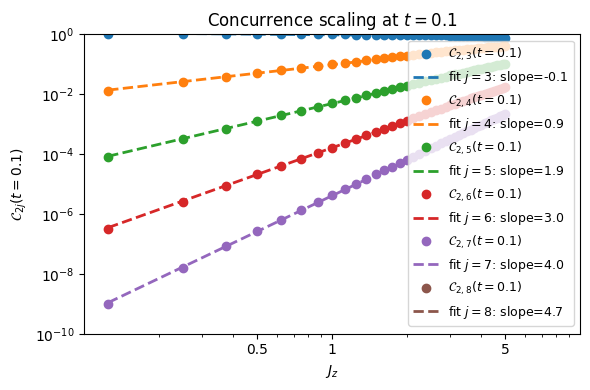

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Extract C_{2j}(t=0.5) vs Jz and fit power laws on a log-log plot
# (NO heatmaps)
# ============================================================

# ---- sweep + targets ----
JzValues  = np.linspace(0, 5, 41)   # includes 0; log-log fit will skip Jz=0
t_target  = 0.1
j_targets = [2,3,4,5,6,7]

# ---- fixed params for file naming ----
i0 = 1
t_max_plot = 1
outdir = "ED_Data/ProjectedJzSweep"

# ---- data containers ----
Jz_list = []
C_at_t  = {j: [] for j in j_targets}

for Jz in JzValues:
    prefix = f"LRb1{Jz*10:.0f}"

    # load concurrence file for this Jz
    df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")

    # time axis (use concurrence time if present, else fall back to magz)
    if "t" in df_conc.columns:
        t = df_conc["t"].values
    else:
        df_mz = pd.read_csv(f"{outdir}/{prefix}magz.csv")
        t = df_mz["t"].values

    mask = t <= t_max_plot
    t_plot = t[mask]
    it = int(np.argmin(np.abs(t_plot - t_target)))
    t_used = float(t_plot[it])

    # extract C_{i0,j} at that time
    Jz_list.append(float(Jz))
    for j in j_targets:
        col = f"C_{i0}_{j}"
        if col in df_conc.columns:
            val = float(df_conc.loc[mask, col].values[it])
        else:
            val = np.nan
        C_at_t[j].append(val)

    # print(f"Jz={Jz:.6g}: used t≈{t_used:.6g}, extracted {', '.join([f'C_2{j}' for j in j_targets])}")

# ============================================================
# LOG–LOG PLOT + FITS:  C_{2j}(t=0.5) vs Jz
# ============================================================
Jz_arr = np.array(Jz_list, dtype=float)

plt.figure(figsize=(6,4))
fit_results = {}

for j in j_targets:
    y = np.array(C_at_t[j], dtype=float)

    # valid points for log-log
    good = np.isfinite(Jz_arr) & np.isfinite(y) & (Jz_arr > 0) & (y > 0)

    if np.sum(good) < 2:
        # print(f"j={j}: not enough valid points to fit.")
        continue

    xg, yg = Jz_arr[good], y[good]

    # log–log fit
    m, b = np.polyfit(np.log10(xg), np.log10(yg), 1)
    fit_results[j] = (m, b)

    # ---- plot data and capture color ----
    (data_line,) = plt.loglog(
        xg, yg,
        marker="o",
        linestyle="none",
        label=rf"$\mathcal{{C}}_{{2,{j+1}}}(t=0.1)$"
    )
    color = data_line.get_color()

    # ---- plot fit with same color, dashed ----
    xfit = np.logspace(np.log10(xg.min()), np.log10(xg.max()), 200)
    yfit = (10**b) * (xfit**m)

    plt.loglog(
        xfit, yfit,
        linestyle="--",
        color=color,
        linewidth=2,
        label=rf"fit $j={j+1}$: slope={m:.1f}"
    )

# force specific x-ticks (log scale)
xticks = [0.5, 1, 5]
plt.xticks(xticks, [str(x) for x in xticks])

plt.xlabel(r"$J_z$")
plt.ylabel(r"$\mathcal{C}_{2j}(t=0.1)$")
plt.title(r"Concurrence scaling at $t=0.1$")
plt.legend(fontsize=9)
plt.xlim(0.1, 10)
plt.ylim(1e-10, 1)
plt.tight_layout()
plt.savefig("plt/c2j_vs_Jz1.pdf", dpi=600)
plt.show()



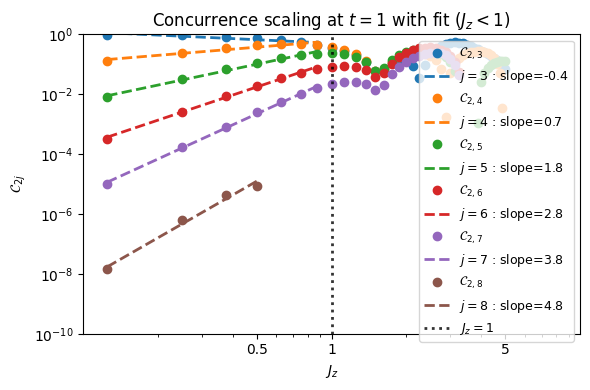

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Extract C_{2j}(t=1) vs Jz and fit power laws on a log-log plot
# Fits are done ONLY for Jz < 1
# ============================================================

# ---- sweep + targets ----
JzValues  = np.linspace(0, 5, 41)   # includes 0; log-log fit will skip Jz=0
t_target  = 1
j_targets = [2, 3, 4, 5, 6, 7]

# ---- fixed params for file naming ----
i0 = 1
t_max_plot = 1
outdir = "ED_Data/ProjectedJzSweep"

# ---- data containers ----
Jz_list = []
C_at_t  = {j: [] for j in j_targets}

for Jz in JzValues:
    prefix = f"LRb1{Jz*10:.0f}"

    # load concurrence file for this Jz
    df_conc = pd.read_csv(f"{outdir}/{prefix}conc.csv")

    # time axis (use concurrence time if present, else fall back to magz)
    if "t" in df_conc.columns:
        t = df_conc["t"].values
    else:
        df_mz = pd.read_csv(f"{outdir}/{prefix}magz.csv")
        t = df_mz["t"].values

    mask = t <= t_max_plot
    t_plot = t[mask]

    it = int(np.argmin(np.abs(t_plot - t_target)))
    t_used = float(t_plot[it])

    # extract C_{i0,j} at that time
    Jz_list.append(float(Jz))
    for j in j_targets:
        col = f"C_{i0}_{j}"
        if col in df_conc.columns:
            val = float(df_conc.loc[mask, col].values[it])
        else:
            val = np.nan
        C_at_t[j].append(val)

# ============================================================
# LOG–LOG PLOT + FITS:  C_{2j}(t=1) vs Jz
# ============================================================
Jz_arr = np.array(Jz_list, dtype=float)

plt.figure(figsize=(6, 4))
fit_results = {}

for j in j_targets:
    y = np.array(C_at_t[j], dtype=float)

    # valid points for plotting (keep all positive Jz, y)
    good_plot = np.isfinite(Jz_arr) & np.isfinite(y) & (Jz_arr > 0) & (y > 0)

    # valid points for fitting: additionally require Jz < 1
    good_fit  = good_plot & (Jz_arr < 1)

    # ---- plot all data (for Jz>0) ----
    if np.sum(good_plot) < 2:
        continue

    xg_plot, yg_plot = Jz_arr[good_plot], y[good_plot]
    (data_line,) = plt.loglog(
        xg_plot, yg_plot,
        marker="o",
        linestyle="none",
        label=rf"$\mathcal{{C}}_{{2,{j+1}}}$"
    )
    color = data_line.get_color()

    # ---- fit only for Jz < 1 ----
    if np.sum(good_fit) >= 2:
        xg_fit, yg_fit = Jz_arr[good_fit], y[good_fit]

        m, b = np.polyfit(np.log10(xg_fit), np.log10(yg_fit), 1)
        fit_results[j] = (m, b)

        # plot fit only over the fitting domain (Jz < 1)
        xfit = np.logspace(np.log10(xg_fit.min()), np.log10(xg_fit.max()), 200)
        yfit = (10**b) * (xfit**m)

        plt.loglog(
            xfit, yfit,
            linestyle="--",
            color=color,
            linewidth=2,
            label=rf"$j={j+1}$ : slope={m:.1f}"
        )

# vertical reference line at Jz = 1 (draw once)
plt.axvline(
    x=1,
    color="k",
    linestyle=":",
    linewidth=2,
    alpha=0.8,
    label=r"$J_z=1$"
)

# force specific x-ticks (log scale)
xticks = [0.5, 1, 5]
plt.xticks(xticks, [str(x) for x in xticks])

plt.xlabel(r"$J_z$")
plt.ylabel(r"$\mathcal{C}_{2j}$")
plt.title(r"Concurrence scaling at $t=1$ with fit ($J_z<1$)")
plt.legend(fontsize=9)
plt.xlim(0.1, 10)
plt.ylim(1e-10, 1)
plt.tight_layout()
plt.savefig("plt/c2j_vs_Jz2.pdf", dpi=600)
plt.show()
